In [9]:
import pandas as pd
import numpy as np



In [10]:
train = pd.read_csv('../data/train_processed.csv')
test  = pd.read_csv('../data/test_processed.csv')


In [11]:
#카드 사용 기간
train['card_duration'] = -train['begin_month']
test['card_duration'] = -test['begin_month']

# 연락 수단 개수
contact_cols = ['FLAG_MOBIL', 'phone', 'work_phone', 'email']
train['contact_count'] = train[contact_cols].sum(axis=1)
test['contact_count']  = test[contact_cols].sum(axis=1)

# 1인당 소득
train['income_per_person'] = train['income_total'] / train['family_size']
test['income_per_person']  = test['income_total'] / test['family_size']


In [12]:
train[['card_duration', 'contact_count', 'income_per_person']].head()


,card_duration,contact_count,income_per_person
0,6.0,1,101250.0
1,5.0,2,82500.0
2,22.0,2,225000.0
3,37.0,2,101250.0
4,26.0,1,78750.0


In [13]:
train.to_csv('../data/fe/train_fe_kisu_v2.csv', index=False)
test.to_csv('../data/fe/test_fe_kisu_v2.csv', index=False)


여기까지 피처링


이후 시각화

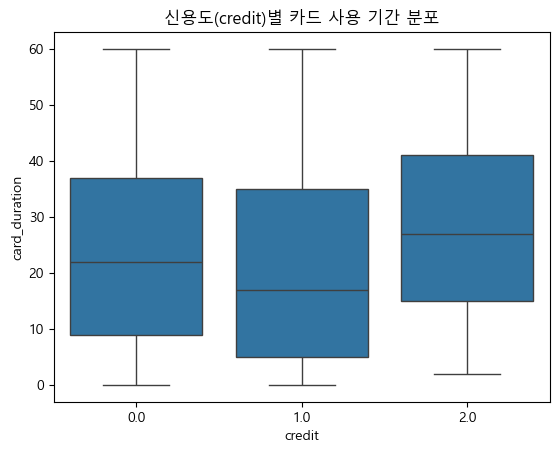

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(x='credit', y='card_duration', data=train)
plt.title('신용도(credit)별 카드 사용 기간 분포')
plt.show()

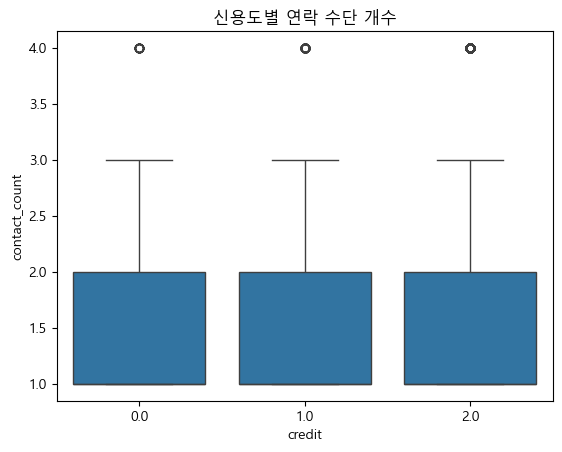

In [15]:
sns.boxplot(x='credit', y='contact_count', data=train)
plt.title('신용도별 연락 수단 개수')
plt.show()

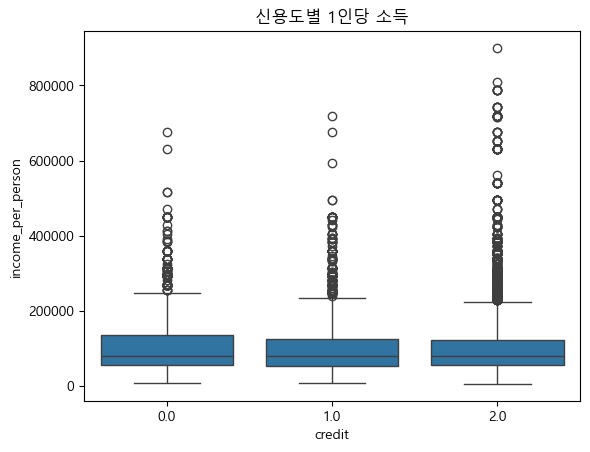

In [16]:
sns.boxplot(x='credit', y='income_per_person', data=train)
plt.title('신용도별 1인당 소득')
plt.show()

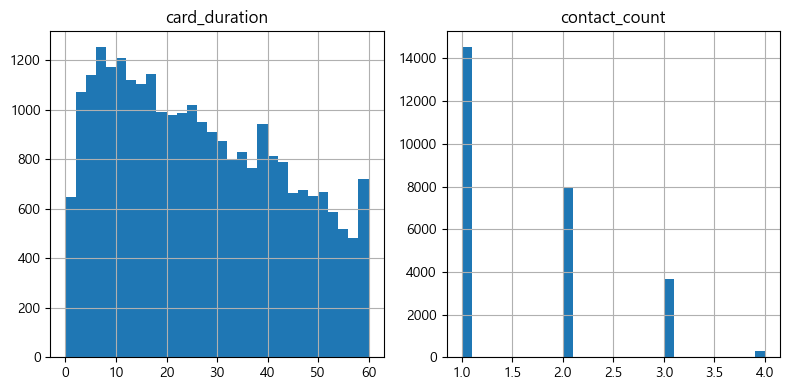

In [17]:
train[['card_duration', 'contact_count']].hist(bins=30, figsize=(8,4))
plt.tight_layout()
plt.show()
